In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from google.colab import drive
drive.mount('/content/drive')
import pickle

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/heart.csv')
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1


([<matplotlib.patches.Wedge at 0x7dc333e9e450>,
 [Text(-0.045501836125125074, 1.0990584984018106, 'No Heart Disease'),
  Text(0.0455018011898916, -1.0990584998481545, 'Heart Disease')],
 [Text(-0.02481918334097731, 0.5994864536737148, '51.3%'),
  Text(0.024819164285395417, -0.5994864544626297, '48.7%')])

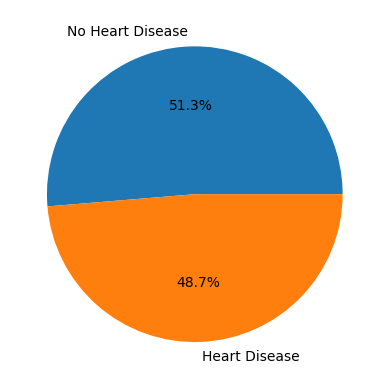

In [ ]:
%matplotlib inline
plt.pie(df['target'].value_counts(), labels=['No Heart Disease', 'Heart Disease'], autopct='%1.1f%%')

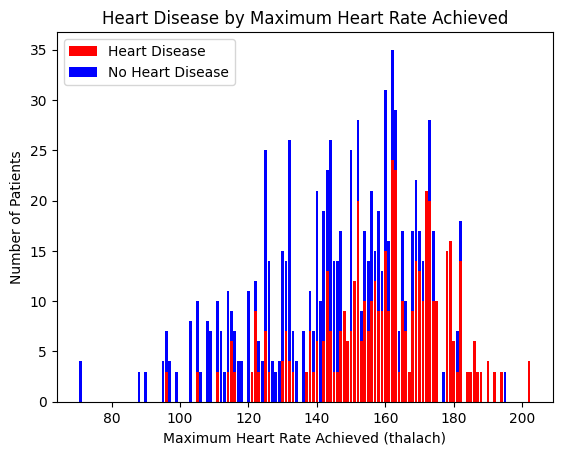

In [ ]:
heart_disease_by_thalach = df.groupby('thalach')['target'].value_counts().unstack().fillna(0)

plt.bar(heart_disease_by_thalach.index, heart_disease_by_thalach[1], label='Heart Disease', color='red')
plt.bar(heart_disease_by_thalach.index, heart_disease_by_thalach[0], label='No Heart Disease', color='blue', bottom=heart_disease_by_thalach[1])

plt.xlabel('Maximum Heart Rate Achieved (thalach)')
plt.ylabel('Number of Patients')
plt.title('Heart Disease by Maximum Heart Rate Achieved')
plt.legend()
plt.show()

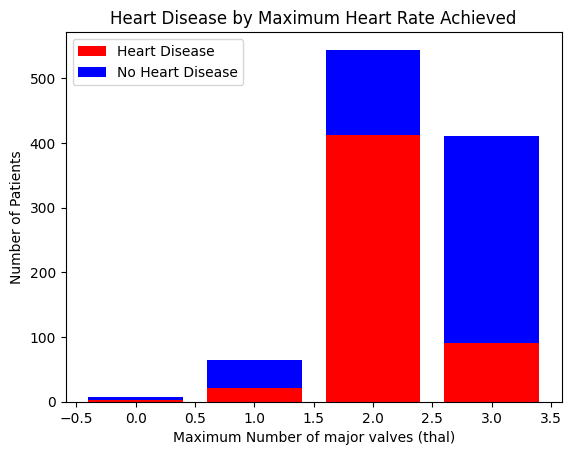

In [ ]:
heart_disease_by_thal = df.groupby('thal')['target'].value_counts().unstack().fillna(0)

plt.bar(heart_disease_by_thal.index, heart_disease_by_thal[1], label='Heart Disease', color='red')
plt.bar(heart_disease_by_thal.index, heart_disease_by_thal[0], label='No Heart Disease', color='blue', bottom=heart_disease_by_thal[1])

plt.xlabel('Maximum Number of major valves (thal)')
plt.ylabel('Number of Patients')
plt.title('Heart Disease by Maximum Heart Rate Achieved')
plt.legend()
plt.show()

In [ ]:
X = df.drop('target', axis=1)
y = df['target']
X = X.drop(['age', 'sex', 'trestbps', 'fbs'], axis=1)
X_Train, X_Test, y_Train, y_Test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training data shape:")
print(X_Train.shape, y_Train.shape)
print("\nTesting data shape:")
print(X_Test.shape, y_Test.shape)

Training data shape:
(820, 9) (820,)

Testing data shape:
(205, 9) (205,)


In [ ]:
tree_model = DecisionTreeClassifier()
tree_model.fit(X_Train, y_Train)

DecisionTreeClassifier()

In [ ]:
from sklearn.metrics import accuracy_score
y_pred = tree_model.predict(X_Test)
accuracy = accuracy_score(y_Test, y_pred)
print(f"Accuracy: {accuracy*100:.2f}%")

Accuracy: 98.54%


In [ ]:
with open('heart_model.pkl', 'wb') as f:
    pickle.dump(tree_model, f)